In [2]:
pip install ucimlrepo

# Preparación de Datos

Dimensiones de X: (1197, 14)
Dimensiones de y: (1197, 1)


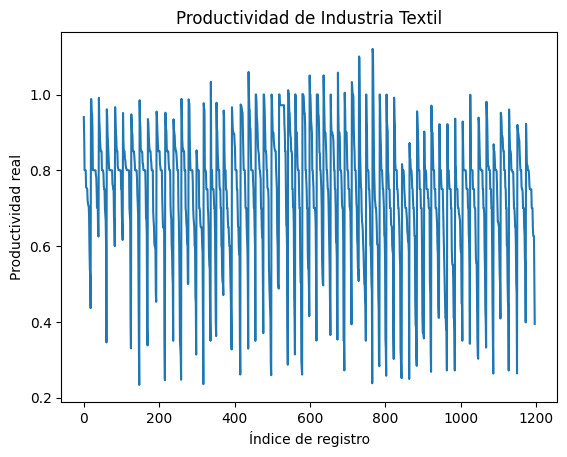

Dimensiones de X: (1197, 21)


/tmp/ipython-input-4215248748.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['date'] = pd.to_datetime(X['date'], errors='coerce')


In [ ]:
# ============================================================================
# MLP para Clasificación — MAGIC Gamma Telescope
# Copyright Jesus David Gelves Cajiao - 3000098650
# Lina Maria Fernandez Garcia - 30000095421
# ============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.callbacks import EarlyStopping
from keras.regularizers import l2


# Descargar dataset desde UCI con su ID
productivity = fetch_ucirepo(id=597)

# Separar características (X) y variable objetivo (y)
X = productivity.data.features   # DataFrame con las variables predictoras
y = productivity.data.targets    # DataFrame con la variable objetivo

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
#print("Primeras filas:\n", X.head())

# Visualizar la variable objetivo
plt.figure()
plt.plot(y.values)
plt.title('Productividad de Industria Textil')
plt.ylabel("Productividad real")
plt.xlabel("Índice de registro")
plt.show()

# Extraer Características de la fecha
if 'date' in X.columns:
    X['date'] = pd.to_datetime(X['date'], errors='coerce')
    X['month'] = X['date'].dt.month
    X['day_of_month'] = X['date'].dt.day
    X = X.drop(columns=['date'])  # eliminamos la original

#Imputar valores faltantes
#X["wip"] = X["wip"].fillna(X["wip"].median())
X = X.drop(columns=['wip'])  # eliminamos la original

# Convertir variables categóricas en variables dummy (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

print("Dimensiones de X:", X.shape)
#("Primeras filas:\n", X.head())

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalar las características numéricas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Modelo 1

In [4]:
# Crear el modelo de red neuronal multicapa (MLP) para regresión
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Capa oculta
    Dense(32, activation='relu'),  # Capa oculta
    Dense(16, activation='relu'),  # Capa oculta
    Dense(1, activation='linear')  # Capa de salida para regresión (1 valor continuo)
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Entrenar el modelo
history = model.fit(X_train, y_train,
                    epochs=200,  # Entrenar durante 100 épocas
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# Evaluar el modelo en el conjunto de prueba
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida en el conjunto de prueba (MSE): {test_loss:.2f}")

# Calcular el RMSE (Raíz del Error Cuadrático Medio)
rmse = np.sqrt(test_loss)
print(f"Raíz del error cuadrático medio (RMSE): {rmse:.2f}")

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular MEA
mae = mean_absolute_error(y_test, y_pred)
print(f"Error absoluto medio (MEA): {mae:.2f}")

# Calcular R^2
r2 = r2_score(y_test, y_pred)
print(f"Coeficiente de determinacion (R^2): {r2:.2f}")

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2994 - val_loss: 0.0908
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0677 - val_loss: 0.0478
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0404 - val_loss: 0.0337
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0295 - val_loss: 0.0306
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0266 - val_loss: 0.0284
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0225 - val_loss: 0.0268
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0213 - val_loss: 0.0257
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0187 - val_loss: 0.0250
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0188 - val_loss: 0.0251
Epoch 10/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0177 - val_loss: 0.0248
Epoch 11/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0163 - val_loss: 0.0246
Epoch 12/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0153 - val_l

# Modelo 2

In [5]:
# Definir segundo modelo
model2 = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),      # Primera capa oculta
    Dropout(0.3),                       # Regularización
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),       # Segunda capa oculta
    Dense(1, activation='linear')       # Capa de salida
])
# Compilar
model2.compile(optimizer=Adam(learning_rate=0.01),loss='mse')

# Early stopping para evitar sobreentrenar
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Entrenamiento
history2 = model2.fit(X_train, y_train,
                      validation_split=0.2,
                      epochs=300,
                      batch_size=16,
                      callbacks=[early_stop],
                      verbose=1)

# Evaluar el modelo en el conjunto de prueba
test_loss2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida en el conjunto de prueba (MSE): {test_loss2:.2f}")

# Calcular el RMSE (Raíz del Error Cuadrático Medio)
rmse2 = np.sqrt(test_loss2)
print(f"Raíz del error cuadrático medio (RMSE): {rmse2:.2f}")

# Realizar predicciones en el conjunto de prueba
y_pred2 = model2.predict(X_test)

# Calcular MEA
mae2 = mean_absolute_error(y_test, y_pred2)
print(f"Error absoluto medio (MEA): {mae2:.2f}")

# Calcular R^2
r2_2 = r2_score(y_test, y_pred2)
print(f"Coeficiente de determinacion (R^2): {r2_2:.2f}")

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.5017 - val_loss: 0.4539
Epoch 2/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3740 - val_loss: 0.1756
Epoch 3/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1651 - val_loss: 0.1003
Epoch 4/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0914 - val_loss: 0.0662
Epoch 5/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0655 - val_loss: 0.0527
Epoch 6/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0518 - val_loss: 0.0412
Epoch 7/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0447 - val_loss: 0.0382
Epoch 8/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0385 - val_loss: 0.0335
Epoch 9/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0363 - val_loss: 0.0352
Epoch 10/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0304 - val_loss: 0.0303
Epoch 11/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0325 - val_loss: 0.0288
Epoch 12/300
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0299 - val_lo

# Modelo 3

In [6]:
# Definir tercer modelo
model3 = Sequential([
    Dense(64, activation='tanh', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh', kernel_regularizer=l2(0.001)),
    Dense(16, activation='tanh', kernel_regularizer=l2(0.001)),
    Dense(1, activation='linear')
])

# Compilar
model3.compile(optimizer=Adam(learning_rate=0.0005),loss='mse')

# Early stopping para evitar sobreentrenar
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Entrenamiento
history3 = model3.fit(X_train, y_train,
                      validation_split=0.2,
                      epochs=300,
                      batch_size=32,
                      callbacks=[early_stop],
                      verbose=1)

# Evaluar el modelo en el conjunto de prueba
test_loss3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida en el conjunto de prueba (MSE): {test_loss3:.2f}")

# Calcular el RMSE (Raíz del Error Cuadrático Medio)
rmse3 = np.sqrt(test_loss3)
print(f"Raíz del error cuadrático medio (RMSE): {rmse3:.2f}")

# Realizar predicciones en el conjunto de prueba
y_pred3 = model3.predict(X_test)

# Calcular MEA
mae3 = mean_absolute_error(y_test, y_pred3)
print(f"Error absoluto medio (MEA): {mae3:.2f}")

# Calcular R^2
r2_3 = r2_score(y_test, y_pred3)
print(f"Coeficiente de determinacion (R^2): {r2_3:.2f}")

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.7381 - val_loss: 0.4603
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3806 - val_loss: 0.2560
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2215 - val_loss: 0.1575
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1474 - val_loss: 0.1308
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1319 - val_loss: 0.1290
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1275 - val_loss: 0.1250
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1204 - val_loss: 0.1254
Epoch 8/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1236 - val_loss: 0.1217
Epoch 9/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1236 - val_loss: 0.1196
Epoch 10/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1168 - val_loss: 0.1192
Epoch 11/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1185 - val_loss: 0.1203
Epoch 12/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1158 - val_l

Pérdida en el conjunto de prueba (MSE): 0.03
Raíz del error cuadrático medio (RMSE): 0.17
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Error absoluto medio (MEA): 0.10
Coeficiente de determinacion (R^2): 0.30


# Resultados de los 3 Modelos

In [11]:
resultados = {
    "Modelo": ["Modelo 1", "Modelo 2", "Modelo 3"],
    "MSE": [test_loss, test_loss2, test_loss3],
    "RMSE": [rmse, rmse2, rmse3],
    "MAE": [mae, mae2, mae3],
    "R^2": [r2, r2_2, r2_3]
}

# Convertir a DataFrame
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.round(4)

print("\nCOMPARATIVA DE RESULTADOS DE LOS MODELOS\n")
print(df_resultados)


COMPARATIVA DE RESULTADOS DE LOS MODELOS

     Modelo     MSE    RMSE     MAE     R^2
0  Modelo 1  0.0359  0.1896  0.1289 -0.3533
1  Modelo 2  0.0265  0.1628  0.1166  0.1624
2  Modelo 3  0.0276  0.1662  0.0962  0.2986


# Graficas de los 3 Modelos

CURVA DE ENTRENAMIENTO DE LOS MODELOS



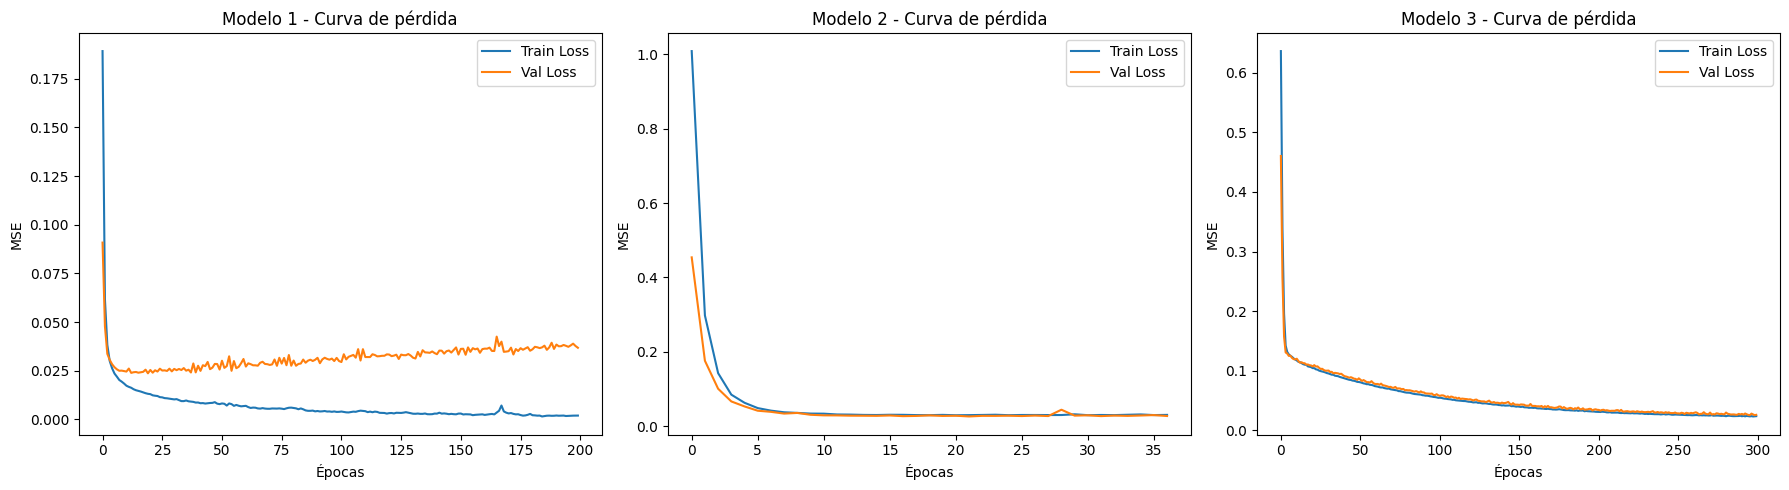


COMPARACIÓN DE SERIES DE LOS MODELOS



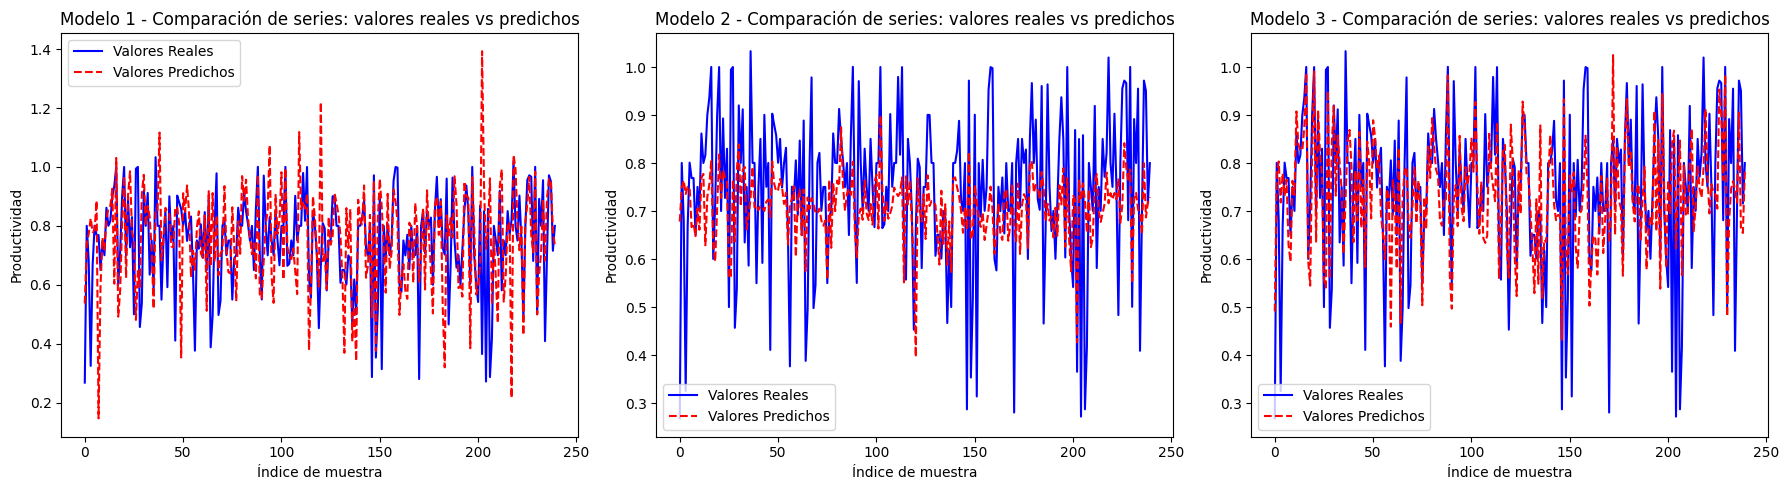


DISPERSIÓN: VALORES REALES VS PREDICHOS DE LOS MODELOS



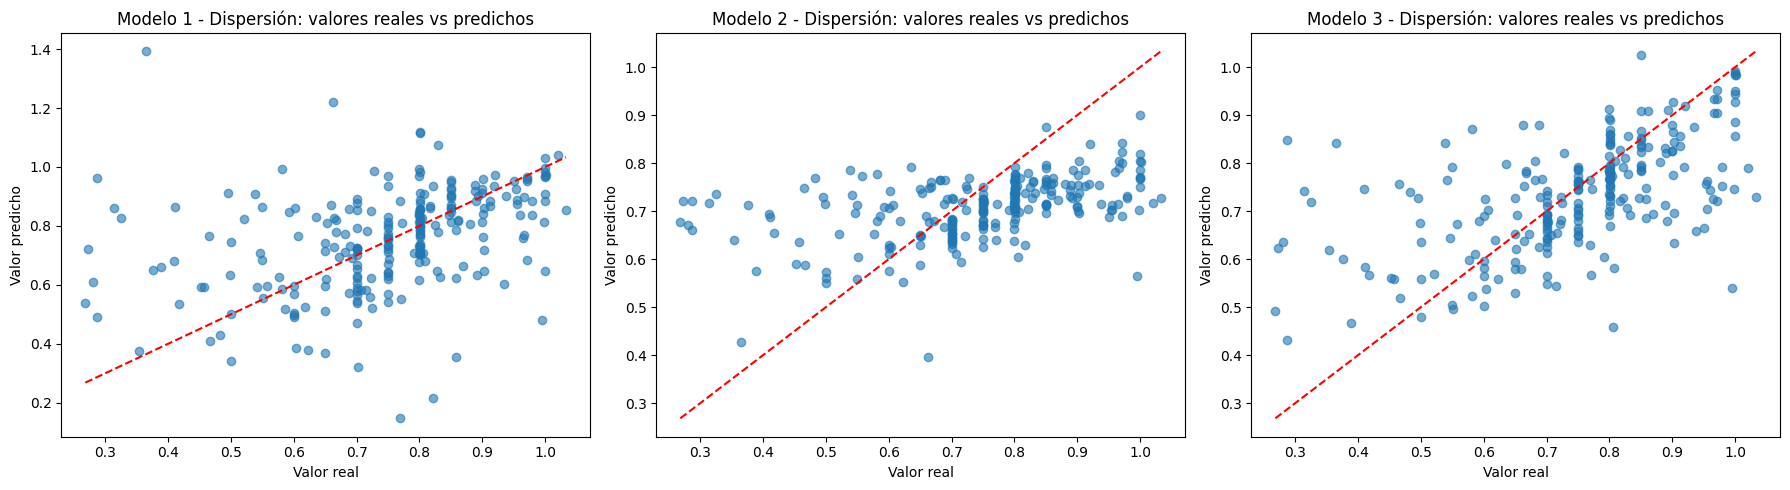

In [12]:
# Curvas de entrenamiento de los tres modelos
print("CURVA DE ENTRENAMIENTO DE LOS MODELOS\n")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))  # 1 fila, 3 columnas

# Modelo 1
axs[0].plot(history.history['loss'], label='Train Loss')
axs[0].plot(history.history['val_loss'], label='Val Loss')
axs[0].set_title("Modelo 1 - Curva de pérdida")
axs[0].set_xlabel("Épocas")
axs[0].set_ylabel("MSE")
axs[0].legend()

# Modelo 2
axs[1].plot(history2.history['loss'], label='Train Loss')
axs[1].plot(history2.history['val_loss'], label='Val Loss')
axs[1].set_title("Modelo 2 - Curva de pérdida")
axs[1].set_xlabel("Épocas")
axs[1].set_ylabel("MSE")
axs[1].legend()

# Modelo 3
axs[2].plot(history3.history['loss'], label='Train Loss')
axs[2].plot(history3.history['val_loss'], label='Val Loss')
axs[2].set_title("Modelo 3 - Curva de pérdida")
axs[2].set_xlabel("Épocas")
axs[2].set_ylabel("MSE")
axs[2].legend()

plt.tight_layout()
plt.show()


# Comparación de series de los tres modelos
print("\nCOMPARACIÓN DE SERIES DE LOS MODELOS\n")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))  # 1 fila, 3 columnas

# Modelo 1
axs[0].plot(range(len(y_test)), y_test, label="Valores Reales", color="blue")
axs[0].plot(range(len(y_pred)), y_pred, label="Valores Predichos", color="red", linestyle="--")
axs[0].set_title("Modelo 1 - Comparación de series: valores reales vs predichos")
axs[0].set_xlabel("Índice de muestra")
axs[0].set_ylabel("Productividad")
axs[0].legend()

# Modelo 2
axs[1].plot(range(len(y_test)), y_test, label="Valores Reales", color="blue")
axs[1].plot(range(len(y_pred2)), y_pred2, label="Valores Predichos", color="red", linestyle="--")
axs[1].set_title("Modelo 2 - Comparación de series: valores reales vs predichos")
axs[1].set_xlabel("Índice de muestra")
axs[1].set_ylabel("Productividad")
axs[1].legend()

# Modelo 3
axs[2].plot(range(len(y_test)), y_test, label="Valores Reales", color="blue")
axs[2].plot(range(len(y_pred3)), y_pred3, label="Valores Predichos", color="red", linestyle="--")
axs[2].set_title("Modelo 3 - Comparación de series: valores reales vs predichos")
axs[2].set_xlabel("Índice de muestra")
axs[2].set_ylabel("Productividad")
axs[2].legend()

plt.tight_layout()
plt.show()

# Dispersión: valores reales vs predichos de los tres modelos
print("\nDISPERSIÓN: VALORES REALES VS PREDICHOS DE LOS MODELOS\n")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))  # 1 fila, 3 columnas

# Modelo 1
axs[0].scatter(y_test, y_pred, alpha=0.6)
axs[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axs[0].set_title("Modelo 1 - Dispersión: valores reales vs predichos")
axs[0].set_xlabel("Valor real")
axs[0].set_ylabel("Valor predicho")

# Modelo 2
axs[1].scatter(y_test, y_pred2, alpha=0.6)
axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axs[1].set_title("Modelo 2 - Dispersión: valores reales vs predichos")
axs[1].set_xlabel("Valor real")
axs[1].set_ylabel("Valor predicho")

# Modelo 3
axs[2].scatter(y_test, y_pred3, alpha=0.6)
axs[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axs[2].set_title("Modelo 3 - Dispersión: valores reales vs predichos")
axs[2].set_xlabel("Valor real")
axs[2].set_ylabel("Valor predicho")

plt.tight_layout()
plt.show()